In [17]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
# === Configuration ===
customer = "Customer_08"
input_folder = fr"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\{customer}"
output_file = os.path.join(input_folder, "yearly_profile.csv")
output_plot = os.path.join(r"C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Plots", f"{customer}.png")
n_year_hours = 8760
rest_timestep_h = 1  # 1-hour resolution during rests

In [19]:
# --- Load all cycle files ---
files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith(".csv")])

In [20]:
# Sort by step number
def parse_step(f):
    m = re.search(r"Step_(\d+)", f)
    return int(m.group(1)) if m else 0

files = sorted(files, key=parse_step)

In [21]:
# Split by type
discharge_files = [f for f in files if "_discharge" in f.lower()]
charge_files = [f for f in files if "_charge" in f.lower()]
n_cycles = min(len(discharge_files), len(charge_files))
print(f"Found {n_cycles} charge/discharge pairs.")

Found 100 charge/discharge pairs.


In [22]:
# --- Read all cycles ---
def read_cycle(file_path, mode):
    df = pd.read_csv(file_path)
    df["mode"] = mode
    return df

discharge_cycles = [read_cycle(os.path.join(input_folder, f), "Discharge") for f in discharge_files]
charge_cycles = [read_cycle(os.path.join(input_folder, f), "Charge") for f in charge_files]
charge_cycles[0]

,time,batt_voltage,batt_current,soc,soh,temperature_M1,temperature_M2,temperature_M3,temperature_M4,temperature_M5,...,cell_voltages_5,cell_voltages_6,cell_voltages_7,cell_voltages_8,cell_voltages_9,cell_voltages_10,cell_voltages_11,cell_voltages_12,cell_voltages_13,mode
0,0,44.101200,-4.405758e-08,0.050000,1,33.000000,33.000000,33.000000,33.000000,33.000000,...,3.392400,3.392400,3.392400,3.392400,3.392400,3.392400,3.392400,3.392400,3.392400,Charge
1,1,44.100938,-1.134219e-01,0.050000,1,33.000000,33.000000,33.000000,33.000000,33.000000,...,3.392383,3.392377,3.392383,3.392383,3.392383,3.392383,3.392352,3.392383,3.392383,Charge
2,2,44.100913,-1.134350e-01,0.050000,1,33.000000,33.000000,33.000000,33.000000,33.000000,...,3.392381,3.392375,3.392381,3.392381,3.392381,3.392381,3.392350,3.392381,3.392381,Charge
3,3,44.100892,-1.134351e-01,0.050000,1,33.000000,33.000000,33.000000,33.000000,33.000000,...,3.392379,3.392374,3.392379,3.392379,3.392379,3.392379,3.392348,3.392379,3.392379,Charge
4,4,44.100874,-1.134351e-01,0.050000,1,33.000000,33.000000,33.000000,33.000000,33.000000,...,3.392378,3.392372,3.392378,3.392378,3.392378,3.392378,3.392347,3.392378,3.392378,Charge
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14843,14843,55.157231,3.787478e+01,0.989922,1,40.125172,40.153344,40.145439,40.139258,40.149392,...,4.241662,4.243582,4.241665,4.241665,4.241665,4.241665,4.254907,4.241664,4.241664,Charge
14844,14844,55.157455,3.778509e+01,0.989945,1,40.125230,40.153409,40.145501,40.139319,40.149455,...,4.241682,4.243598,4.241685,4.241685,4.241685,4.241685,4.254895,4.241684,4.241684,Charge
14845,14845,55.157678,3.769583e+01,0.989967,1,40.125288,40.153472,40.145563,40.139380,40.149518,...,4.241702,4.243614,4.241705,4.241705,4.241705,4.241705,4.254882,4.241705,4.241705,Charge
14846,14846,55.157901,3.760702e+01,0.989989,1,40.125345,40.153536,40.145625,40.139440,40.149580,...,4.241722,4.243629,4.241725,4.241725,4.241725,4.241725,4.254870,4.241725,4.241725,Charge


In [23]:
# --- Compute total active duration (sum of all cycles) ---
total_active_seconds = sum(df["time"].iloc[-1] for df in discharge_cycles + charge_cycles)
active_hours = total_active_seconds / 3600
available_rest_hours = max(n_year_hours - active_hours, 0)
rest_hours_each = available_rest_hours / (2 * n_cycles)  # two rests per cycle pair

print(f"Active hours: {active_hours:.1f} h")
print(f"Each rest: {rest_hours_each:.2f} h")

Active hours: 873.8 h
Each rest: 39.43 h


In [24]:
# --- Identify temperature and cell voltage columns ---
temp_cols = [c for c in discharge_cycles[0].columns if c.startswith("temperature_M")]
cell_cols = [c for c in discharge_cycles[0].columns if c.startswith("cell_voltages_")]

In [25]:
def smooth_relaxation_exponential(x_start, x_end, t, rel_tol=5e-3):
    """
    Exponential relaxation from x_start -> x_end over times t (seconds).
    rel_tol: relative tolerance at t[-1] (e.g. 1e-3 => within 0.1% before forcing the final point).
    Returns array same length as t. Ensures value[0]=x_start and value[-1]=x_end.
    Works for x_end > x_start and x_end < x_start.
    """
    t = np.asarray(t, dtype=float)
    if t.size == 0:
        return np.array([], dtype=float)

    if np.isclose(x_start, x_end):
        return np.full_like(t, x_start, dtype=float)

    t_end = max(t[-1], 1e-9)
    eps = float(rel_tol)
    # choose tau so that exp(-t_end/tau) ~ eps  => tau = -t_end / ln(eps)
    tau = -t_end / np.log(eps) if eps > 0 else t_end

    y = x_end + (x_start - x_end) * np.exp(-t / tau)
    # Force exact endpoints to avoid tiny residual mismatch:
    y[0] = x_start
    y[-1] = x_end
    return y

In [26]:
n_cycles

100

In [27]:
# --- Build the yearly profile ---
year_segments = []
current_time_s = 0

for i in range(n_cycles):
    d = discharge_cycles[i].copy()
    c = charge_cycles[i].copy()
        
    # Adjust discharge time offset
    d["time"] = d["time"] + current_time_s
    current_time_s = d["time"].iloc[-1] + 1
    
    # --- Storage between Discharge and Charge ---
    rest_t1 = np.arange(0, rest_hours_each * 3600, rest_timestep_h * 3600)
    rest_t1 = np.append(rest_t1, rest_t1[-1] + round((rest_hours_each % 1)*3600))
    rest_t1 += current_time_s
    rest1 = pd.DataFrame({"time": rest_t1, "mode": "Storage"})
    
    # Fill constant columns
    rest1["batt_current"] = 0
    rest1["soc"] = d["soc"].iloc[-1]
    rest1["soh"] = d["soh"].iloc[-1]
    
    # Interpolate voltages (pack + cell) and temperatures
    v_start = d["batt_voltage"].iloc[-1]
    v_next = c["batt_voltage"].iloc[0]
    rest1["batt_voltage"] = smooth_relaxation_exponential(v_start, v_next, rest_t1)
    
    # Interpolate voltages (pack + cell) and temperatures
    v_start = d["batt_voltage"].iloc[-1]
    v_next = c["batt_voltage"].iloc[0]
    rest1["batt_voltage"] = smooth_relaxation_exponential(v_start, v_next, rest_t1)
    
    for col in temp_cols:
        t_start = d[col].iloc[-1]
        t_next = c[col].iloc[0]
        rest1[col] = smooth_relaxation_exponential(t_start, t_next, rest_t1)
    
    for col in cell_cols:
        v_start = d[col].iloc[-1]
        v_next = c[col].iloc[0]
        rest1[col] = smooth_relaxation_exponential(v_start, v_next, rest_t1)
    
    current_time_s = rest1["time"].iloc[-1]
    
    # Adjust charge time offset
    c["time"] = c["time"] + current_time_s + 1
    current_time_s = c["time"].iloc[-1] + 1
    
    # --- Storage between Charge and next Discharge ---
    rest_t2 = np.arange(0, rest_hours_each * 3600, rest_timestep_h * 3600)
    rest_t2 = np.append(rest_t2, rest_t2[-1] + round((rest_hours_each % 1)*3600))
    rest_t2 += current_time_s
    rest2 = pd.DataFrame({"time": rest_t2, "mode": "Storage"})
    
    rest2["batt_current"] = 0
    rest2["soc"] = c["soc"].iloc[-1]
    rest2["soh"] = c["soh"].iloc[-1]
    
    if i < n_cycles - 1:
        d_next = discharge_cycles[i + 1]
        v_next = d_next["batt_voltage"].iloc[0]
        rest2["batt_voltage"] = smooth_relaxation_exponential(c["batt_voltage"].iloc[-1], v_next, rest_t2)
        for col in temp_cols:
            t_next = d_next[col].iloc[0]
            t_start = c[col].iloc[-1]
            rest2[col] = smooth_relaxation_exponential(t_start, t_next, rest_t2)
        for col in cell_cols:
            v_start = c[col].iloc[-1]
            v_next = d_next[col].iloc[0]
            rest2[col] = smooth_relaxation_exponential(v_start, v_next, rest_t2)
    else:
        # Final relaxation to nominal
        rest2["batt_voltage"] = smooth_relaxation_exponential(c["batt_voltage"].iloc[-1], 3.7*13, rest_t2)
        for col in temp_cols:
            t_start = c[col].iloc[-1]
            rest2[col] = smooth_relaxation_exponential(t_start, 25, rest_t2)
        for col in cell_cols:
            v_start = c[col].iloc[-1]
            rest2[col] = smooth_relaxation_exponential(v_start, 3.7, rest_t2)
    
    current_time_s = rest2["time"].iloc[-1] + 1
    
    # Append segments
    year_segments.extend([d, rest1, c, rest2])

In [28]:
# --- Combine all ---
year_df = pd.concat(year_segments, ignore_index=True)
year_df.drop(year_df.tail(1).index, inplace=True)
time_series = year_df["time"].copy()
time_series.iloc[-1] = 365 * 24 * 3600
year_df["time"] = time_series
year_df["time_h"] = year_df["time"] / 3600
year_df

,time,batt_voltage,batt_current,soc,soh,temperature_M1,temperature_M2,temperature_M3,temperature_M4,temperature_M5,...,cell_voltages_6,cell_voltages_7,cell_voltages_8,cell_voltages_9,cell_voltages_10,cell_voltages_11,cell_voltages_12,cell_voltages_13,mode,time_h
0,0.0,54.990000,-5.493506e-08,1.000000,1.000,36.000000,36.000000,36.000000,36.000000,36.000000,...,4.230000,4.230000,4.230000,4.230000,4.230000,4.230000,4.230000,4.230000,Discharge,0.000000
1,1.0,54.990000,-5.493506e-08,1.000000,1.000,36.000000,36.000000,36.000000,36.000000,36.000000,...,4.230000,4.230000,4.230000,4.230000,4.230000,4.230000,4.230000,4.230000,Discharge,0.000278
2,2.0,54.989817,-9.098148e-02,1.000000,1.000,36.000000,36.000000,36.000000,36.000000,36.000000,...,4.229984,4.229988,4.229988,4.229988,4.229988,4.229963,4.229988,4.229988,Discharge,0.000556
3,3.0,54.989802,-9.099198e-02,1.000000,1.000,36.000000,36.000000,36.000000,36.000000,36.000000,...,4.229983,4.229987,4.229987,4.229987,4.229987,4.229962,4.229987,4.229987,Discharge,0.000833
4,4.0,54.989790,-9.099200e-02,1.000000,1.000,36.000000,36.000000,36.000000,36.000000,36.000000,...,4.229982,4.229986,4.229986,4.229986,4.229986,4.229961,4.229986,4.229986,Discharge,0.001111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3154199,31520453.0,48.132968,0.000000e+00,0.980036,0.963,25.025989,25.026146,25.026102,25.026068,25.026124,...,3.702512,3.702712,3.702606,3.702430,3.702521,3.702335,3.702572,3.702759,Storage,8755.681389
3154200,31524053.0,48.132948,0.000000e+00,0.980036,0.963,25.025974,25.026131,25.026086,25.026052,25.026108,...,3.702510,3.702710,3.702605,3.702429,3.702519,3.702334,3.702571,3.702757,Storage,8756.681389
3154201,31527653.0,48.132928,0.000000e+00,0.980036,0.963,25.025958,25.026115,25.026071,25.026036,25.026093,...,3.702509,3.702708,3.702603,3.702427,3.702518,3.702332,3.702569,3.702756,Storage,8757.681389
3154202,31531253.0,48.132908,0.000000e+00,0.980036,0.963,25.025942,25.026099,25.026055,25.026021,25.026077,...,3.702507,3.702707,3.702602,3.702426,3.702516,3.702331,3.702568,3.702754,Storage,8758.681389


In [29]:
# --- Save output ---
year_df.to_csv(output_file, index=False)
print(f"\n✅ Yearly profile saved to {output_file}")


✅ Yearly profile saved to C:\Users\mmackenzie\OneDrive - ZELEROS GLOBAL S.L\Documents\Synthetic data\Customer_08\yearly_profile.csv


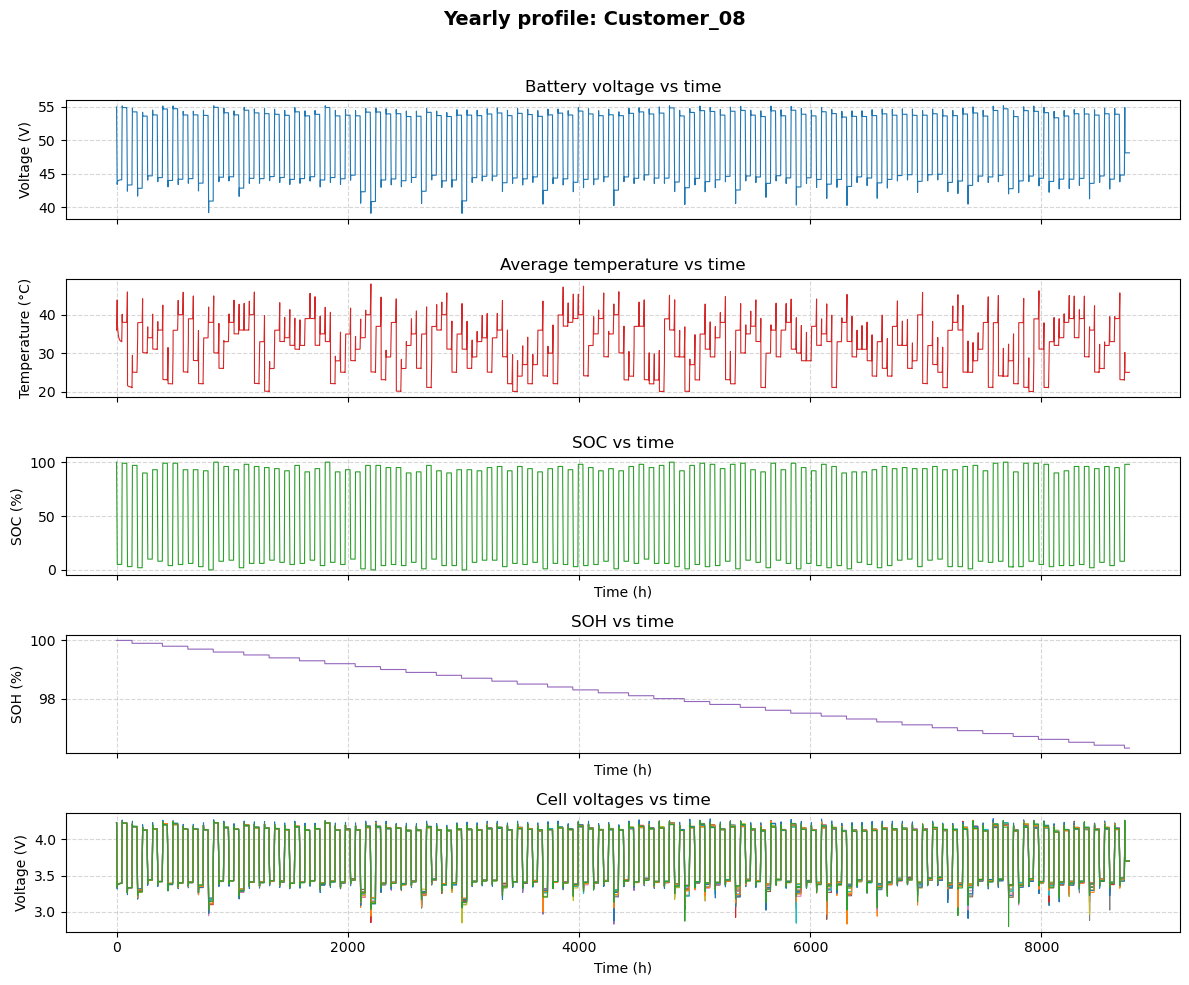

<Figure size 640x480 with 0 Axes>

In [30]:
# --- Pack level visualization ---
fig, axs = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
plt.subplots_adjust(hspace=0.3)
fig.suptitle(f"Yearly profile: {customer}", fontsize=14, fontweight="bold")

# Voltage
axs[0].plot(year_df["time_h"], year_df["batt_voltage"], color="tab:blue", lw=0.8)
axs[0].set_ylabel("Voltage (V)")
axs[0].grid(True, linestyle="--", alpha=0.5)
axs[0].set_title("Battery voltage vs time")

# Temperature (average of M1–M5)
avg_temp = year_df[temp_cols].mean(axis=1)
axs[1].plot(year_df["time_h"], avg_temp, color="tab:red", lw=0.8)
axs[1].set_ylabel("Temperature (°C)")
axs[1].grid(True, linestyle="--", alpha=0.5)
axs[1].set_title("Average temperature vs time")

# SOC
axs[2].plot(year_df["time_h"], year_df["soc"]*100, color="tab:green", lw=0.8)
axs[2].set_ylabel("SOC (%)")
axs[2].set_xlabel("Time (h)")
axs[2].grid(True, linestyle="--", alpha=0.5)
axs[2].set_title("SOC vs time")

# SOH
axs[3].plot(year_df["time_h"], year_df["soh"]*100, color="tab:purple", lw=0.8)
axs[3].set_ylabel("SOH (%)")
axs[3].set_xlabel("Time (h)")
axs[3].grid(True, linestyle="--", alpha=0.5)
axs[3].set_title("SOH vs time")

# Cell voltages
for col in cell_cols:
    axs[4].plot(year_df["time_h"], year_df[col], lw=0.8, label=col)
axs[4].set_ylabel("Voltage (V)")
axs[4].grid(True, linestyle="--", alpha=0.5)
axs[4].set_title("Cell voltages vs time")
axs[4].set_xlabel("Time (h)")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
plt.savefig(output_plot, dpi=300, bbox_inches="tight")

In [145]:
%matplotlib qt